# 08 — Gaussian Transforms, Uncertainty, Time-Frequency Tradeoff, and Information

## Learning goals

- See that a Gaussian transforms into another Gaussian.
- Understand why narrow in time means broad in frequency.
- Connect this tradeoff to Heisenberg-style uncertainty.
- Use a simple spectrogram to watch frequency change over time.
- Interpret information rate as a sum over frequency bands.

## Mental model

Fourier uncertainty is like squeezing a balloon: squeeze it in time and it bulges in frequency. Squeeze it in frequency and it spreads in time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 4.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

def stem_spectrum(freqs, values, title="Spectrum", xlabel="Frequency", ylabel="Amplitude"):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    markerline, stemlines, baseline = ax.stem(freqs, values, basefmt=" ")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    plt.show()

## Gaussian width tradeoff

A Gaussian with time standard deviation $\sigma_t$ has a Gaussian-shaped transform with reciprocal angular-frequency width:

$$\sigma_t\sigma_\omega \approx 1.$$

The exact constant depends on convention and normalization, but the inverse-width mental model is the key.

<>:39: SyntaxWarning: invalid escape sequence '\o'
<>:39: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_6055/3642148178.py:39: SyntaxWarning: invalid escape sequence '\o'
  ax2.set_xlabel("Angular frequency $\omega$")


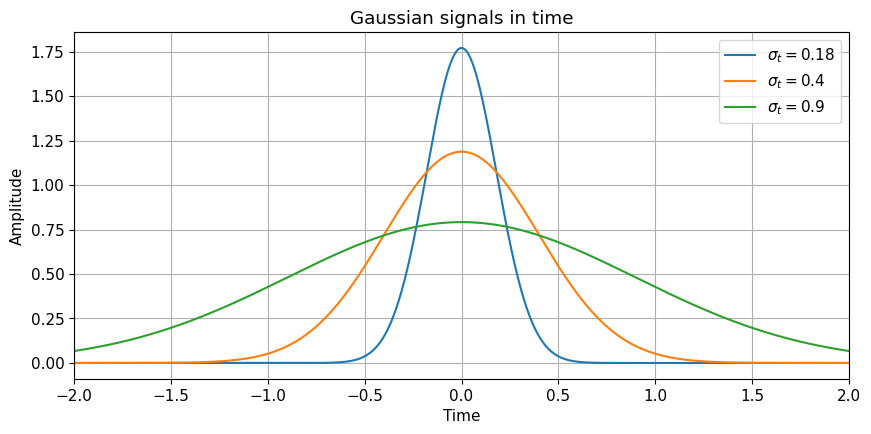

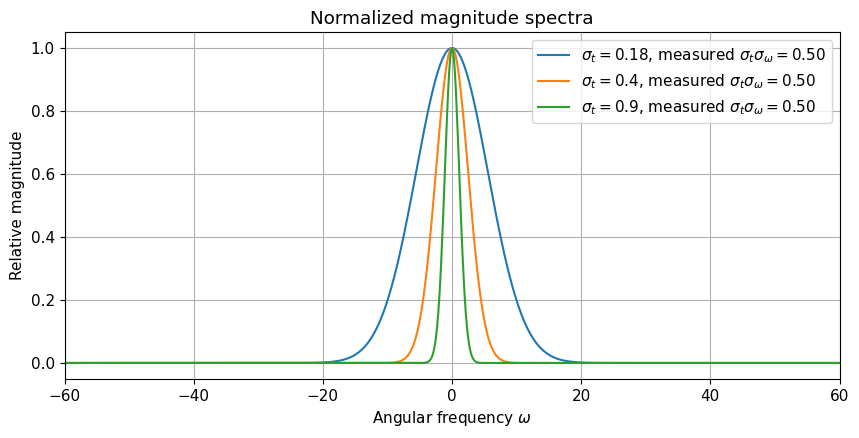

In [2]:
def centered_fft(f, dt):
    F = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(f))) * dt
    freq = np.fft.fftshift(np.fft.fftfreq(len(f), d=dt))
    omega = 2*np.pi*freq
    return omega, F

def weighted_std(x, weights):
    weights = np.maximum(weights, 0)
    weights = weights / weights.sum()
    mu = np.sum(x*weights)
    return np.sqrt(np.sum(weights*(x-mu)**2))

N = 8192
dt = 0.005
t = (np.arange(N)-N//2)*dt
sigmas = [0.18, 0.40, 0.90]

fig1, ax1 = plt.subplots(figsize=(10, 4.5))
fig2, ax2 = plt.subplots(figsize=(10, 4.5))

for sigma_t in sigmas:
    f = np.exp(-t**2/(2*sigma_t**2))
    f /= np.sqrt(np.sum(np.abs(f)**2)*dt)  # energy normalize
    omega, F = centered_fft(f, dt)
    power_t = np.abs(f)**2
    power_w = np.abs(F)**2
    st = weighted_std(t, power_t)
    sw = weighted_std(omega, power_w)
    ax1.plot(t, f, label=fr"$\sigma_t={sigma_t}$")
    ax2.plot(omega, np.abs(F)/np.max(np.abs(F)), label=fr"$\sigma_t={sigma_t}$, measured $\sigma_t\sigma_\omega={st*sw:.2f}$")

ax1.set_xlim(-2, 2)
ax1.set_title("Gaussian signals in time")
ax1.set_xlabel("Time")
ax1.set_ylabel("Amplitude")
ax1.legend()
ax2.set_xlim(-60, 60)
ax2.set_title("Normalized magnitude spectra")
ax2.set_xlabel("Angular frequency $\omega$")
ax2.set_ylabel("Relative magnitude")
ax2.legend()
plt.show()

## Pure tone versus short pulse

A pure tone is spread across all time but concentrated in frequency. A short pulse is concentrated in time but spread across frequency.

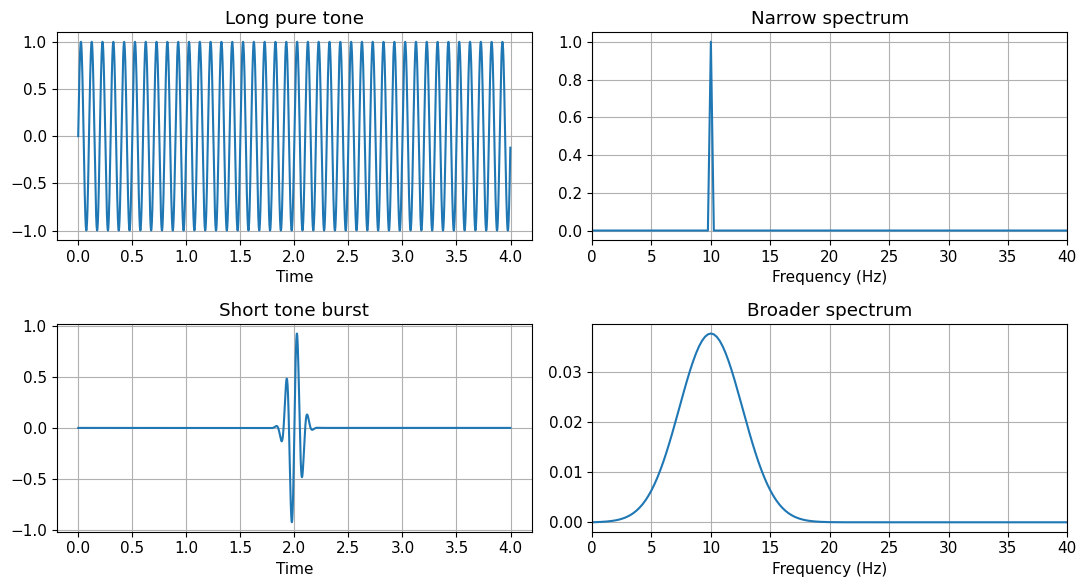

In [3]:
R = 512
T = 4
N = R*T
t = np.arange(N)/R

tone = np.sin(2*np.pi*10*t)
pulse = np.exp(-(t-2)**2/(2*0.06**2)) * np.sin(2*np.pi*10*t)

def one_sided_amp(x, R):
    N = len(x)
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(N, d=1/R)
    A = 2*np.abs(X)/N
    A[0] = np.abs(X[0])/N
    return f, A

f_tone, A_tone = one_sided_amp(tone, R)
f_pulse, A_pulse = one_sided_amp(pulse, R)

fig, axs = plt.subplots(2, 2, figsize=(11, 6))
axs[0,0].plot(t, tone)
axs[0,0].set_title("Long pure tone")
axs[0,0].set_xlabel("Time")
axs[0,1].plot(f_tone, A_tone)
axs[0,1].set_xlim(0, 40)
axs[0,1].set_title("Narrow spectrum")
axs[0,1].set_xlabel("Frequency (Hz)")
axs[1,0].plot(t, pulse)
axs[1,0].set_title("Short tone burst")
axs[1,0].set_xlabel("Time")
axs[1,1].plot(f_pulse, A_pulse)
axs[1,1].set_xlim(0, 40)
axs[1,1].set_title("Broader spectrum")
axs[1,1].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

## Spectrogram: trading detail in time and frequency

A spectrogram computes many short-window Fourier transforms. Short windows give better time localization but worse frequency resolution. Long windows do the opposite.

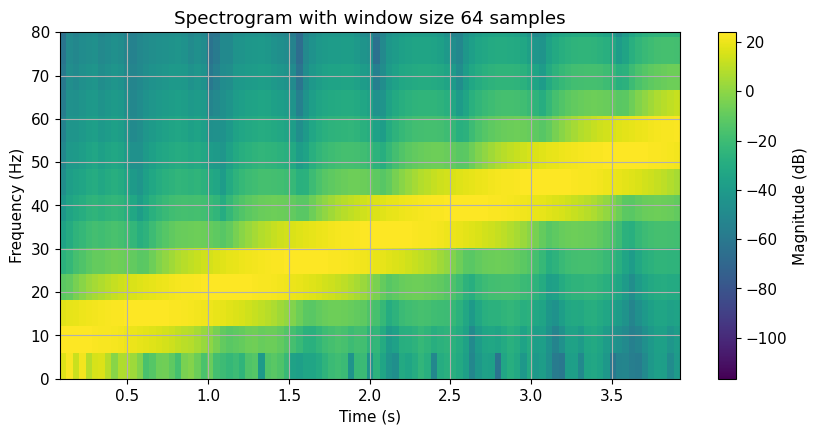

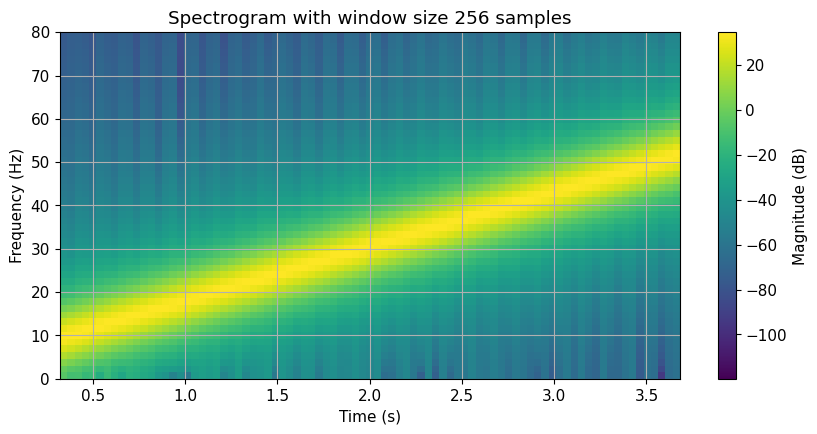

In [4]:
def stft_magnitude(x, R, window_size, hop):
    window = np.hanning(window_size)
    frames = []
    times = []
    for start in range(0, len(x)-window_size+1, hop):
        frame = x[start:start+window_size] * window
        frames.append(np.abs(np.fft.rfft(frame)))
        times.append((start + window_size/2)/R)
    frames = np.array(frames).T
    freqs = np.fft.rfftfreq(window_size, d=1/R)
    return np.array(times), freqs, frames

R = 400
T = 4
N = R*T
t = np.arange(N)/R
# chirp with instantaneous frequency increasing from 5 to 55 Hz
f0, f1 = 5, 55
k = (f1-f0)/T
phase = 2*np.pi*(f0*t + 0.5*k*t**2)
chirp = np.sin(phase)

for window_size in [64, 256]:
    times, freqs, S = stft_magnitude(chirp, R, window_size, hop=16)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    im = ax.imshow(20*np.log10(S+1e-6), origin="lower", aspect="auto",
                   extent=[times[0], times[-1], freqs[0], freqs[-1]])
    ax.set_ylim(0, 80)
    ax.set_title(f"Spectrogram with window size {window_size} samples")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    fig.colorbar(im, ax=ax, label="Magnitude (dB)")
    plt.show()

## Information as a sum over frequency bands

For a Gaussian signal-plus-noise channel, the contribution of a frequency band depends on its signal-to-noise ratio:

$$I(\nu) = \log_2\left(1 + \frac{S(\nu)}{N(\nu)}\right).$$

The total rate is the integral, or in sampled form the sum, across frequency bands.

/tmp/ipykernel_6055/307417928.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_rate = np.trapz(I_per_hz, freq)


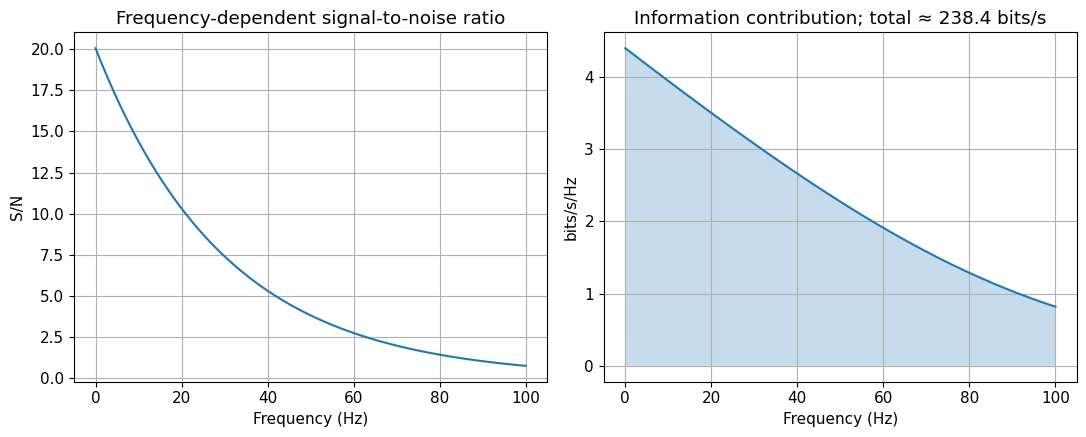

In [5]:
freq = np.linspace(0, 100, 500)
S_over_N = 20*np.exp(-freq/30) + 0.05
I_per_hz = np.log2(1 + S_over_N)
total_rate = np.trapz(I_per_hz, freq)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
axs[0].plot(freq, S_over_N)
axs[0].set_title("Frequency-dependent signal-to-noise ratio")
axs[0].set_xlabel("Frequency (Hz)")
axs[0].set_ylabel("S/N")
axs[1].plot(freq, I_per_hz)
axs[1].fill_between(freq, I_per_hz, alpha=0.25)
axs[1].set_title(f"Information contribution; total ≈ {total_rate:.1f} bits/s")
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_ylabel("bits/s/Hz")
plt.tight_layout()
plt.show()

## Checkpoint

1. Make the Gaussian narrower. What happens to its spectrum?
2. Change the STFT window size. Which plot gives a sharper estimate of time? Which gives a sharper estimate of frequency?
3. In the information example, increase noise at high frequencies. What happens to the total rate?